In [148]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install astropy
%pip install scipy
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
import astropy
import math

In [150]:
data = pd.read_csv('M101.csv')
data.head()

mag_data = data['inst_vega_mag2'].values

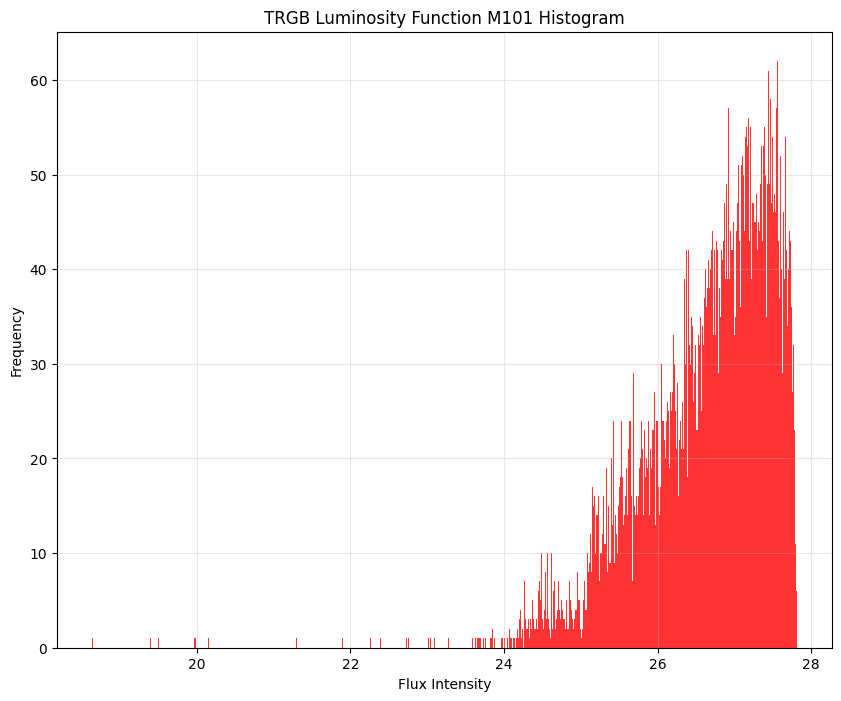

In [155]:
fig_hist, ax_hist = plt.subplots(figsize=(10, 8))

ax_hist.hist(mag_data, bins=bins, color='red', alpha=0.8)
ax_hist.set_xlabel('Flux Intensity')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(True, alpha=0.3)
ax_hist.set_title('TRGB Luminosity Function M101 Histogram')

fig_hist.savefig('TRGB Luminosity Function M101 Histogram')

In [156]:
def gloess(mag, tau, bin_width = 0.01):
    fig_gloess, ax_gloess = plt.subplots(figsize = (10, 10))
    hist, bins, cont = ax_gloess.hist(mag, bins = np.arange(min(mag), max(mag) + bin_width, bin_width), color = 'black')
    plt.close()
    bin_centers = []
    for j in range(len(bins) - 1):
        bin_centers.append((bins[j] + bins[j + 1]) / 2)
    yest = np.zeros(len(hist))
    w = np.array([np.exp(- (bin_centers - bin_centers[i])**2/(2 * tau**2)) for i in range(len(hist))])
    for i in range(len(hist)):
        weights = w[i, :]
        b = np.array([np.sum(weights * hist), np.sum(weights * hist * bin_centers)])
        A = np.array([[np.sum(weights), np.sum(weights * bin_centers)],
                    [np.sum(weights * bin_centers), np.sum(weights * bin_centers * bin_centers)]])
        theta = linalg.solve(A, b)
        yest[i] = theta[0] + theta[1] * bin_centers[i]
    return yest, np.array(bin_centers)

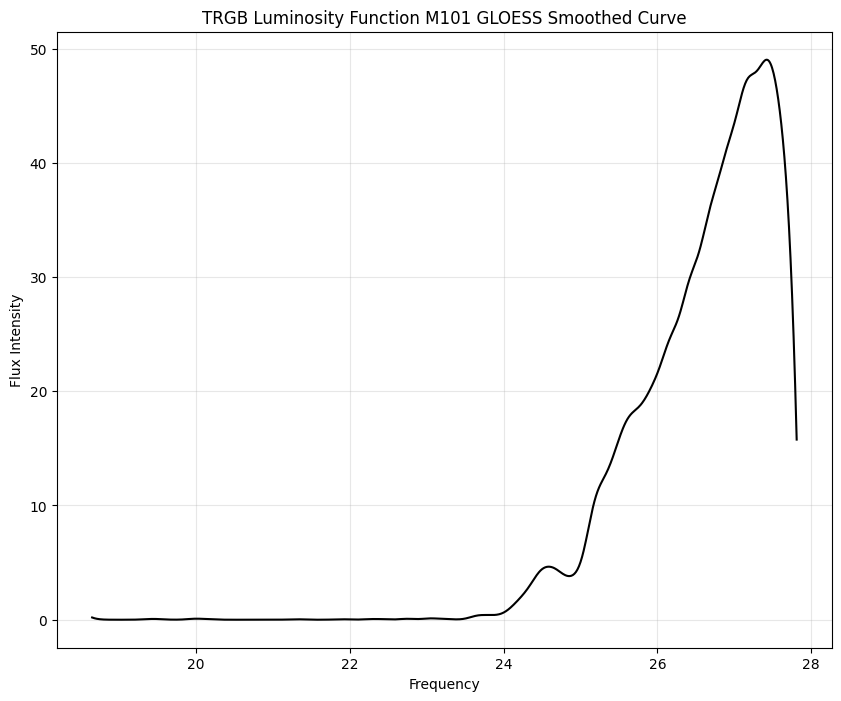

In [157]:
fig_sm, ax_sm = plt.subplots(figsize=(10, 8))

Y, X = gloess(mag_data, 0.10)
ax_sm.plot(X, Y, color='black')
ax_sm.set_ylabel('Flux Intensity')
ax_sm.set_xlabel('Frequency')
ax_sm.grid(True, alpha=0.3)
ax_sm.set_title('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

fig_sm.savefig('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

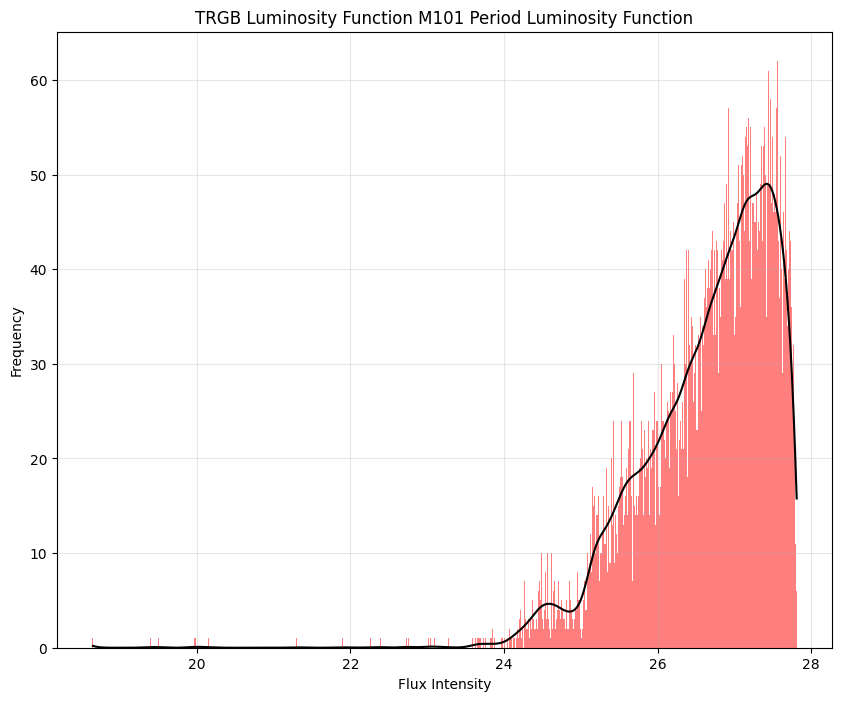

In [158]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(mag_data, bins=bins, color='red', alpha=0.5)
ax.plot(X, Y, color='black')
ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
ax.set_title('TRGB Luminosity Function M101 Period Luminosity Function')

fig.savefig('TRGB Luminosity Function M101 Period Luminosity Function')